In [1]:
import h5py
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })
from matplotlib.colors import Normalize
import corner
import jax

from jesterTOV.inference.population.populations import RecycledBinary

# load EOS
m_val, r_val, l_val = np.loadtxt("../../../eos/RMF3_MRL.dat", unpack=True)
mtov = m_val.max()
n_val, p_val = np.loadtxt("../../../eos/RMF3_cold_beta_lamb.d", unpack=True, usecols=[1,3])

events = pd.read_csv("../events.dat", sep=" ")
latex_labels={"mu_1": "$\\mu_1$", "mu_2": "$\\mu_2$", "sigma_1": "$\\sigma_1$", "sigma_2": "$\\sigma_2$", "alpha": "$\\alpha$", "m_min": "$m_{\\rm{min}}$", "m_max": "$m_{\\rm{max}}$" }


In [2]:
def load_population_posterior(file):

    posterior = {}

    with h5py.File(file) as f:

        for key in ["mu_1", "mu_2", "alpha", "sigma_1", "sigma_2", "m_max", "m_min", "k_coll"]:
            if key in f["posterior"]["parameters"].keys():
                posterior[key] = f["posterior"]["parameters"][key][:]
        
        posterior["log_prob"] = f["posterior"]["log_prob"][:]
    
    return pd.DataFrame(posterior)

def load_eos_posterior(file):
    
    posterior = {}

    with h5py.File(file) as f:
        posterior["masses_EOS"] = f["posterior"]["derived_eos"]["masses_EOS"][:]
        posterior["radii_EOS"] = f["posterior"]["derived_eos"]["radii_EOS"][:]
        posterior["lambdas_EOS"] = f["posterior"]["derived_eos"]["Lambdas_EOS"][:]
        posterior["log_prob"] = f["posterior"]["log_prob"][:]

    return posterior

def get_population_hist(params, bins, size=10_000):
    
    m1samp, m2samp = RecycledBinary(jax.random.key(42), params, size=size)

    hist1, _ = np.histogram(m1samp, bins=bins, density=True)
    hist2, _ = np.histogram(m2samp, bins=bins, density=True)

    return hist1, hist2

def plot_population(pop_posterior, ax, color="purple"):

    mbins = np.linspace(1.1, 1.7, 80)
    mx = 0.5*(mbins[1:] + mbins[:-1])

    hist1_arr = np.zeros((pop_posterior.shape[0], mbins.size-1))
    hist2_arr = np.zeros((pop_posterior.shape[0], mbins.size-1))

    for j in range(pop_posterior.shape[0]):

        hist1, hist2 = get_population_hist(pop_posterior.loc[j].to_dict(), bins=mbins)
        hist1_arr[j] = hist1
        hist2_arr[j] = hist2

    hist1_quantiles = np.quantile(hist1_arr, q=[0.025, 0.16, 0.5, 0.84, 0.975], axis=0)
    hist2_quantiles = np.quantile(hist2_arr, q=[0.025, 0.16, 0.5, 0.84, 0.975], axis=0)

    #ax[0].plot(mx, hist1_quantiles[1], color=color, linestyle="dashed")
    #ax[0].plot(mx, hist1_quantiles[3], color=color, linestyle="dashed")
    ax[0].fill_between(mx, hist1_quantiles[0], hist1_quantiles[-1], color=color, alpha=0.1)


    #ax[1].plot(mx, hist2_quantiles[1], color=color, linestyle="dashed")
    #ax[1].plot(mx, hist2_quantiles[3], color=color, linestyle="dashed")
    ax[1].fill_between(mx, hist2_quantiles[0], hist2_quantiles[-1], color=color, alpha=0.1)
    

    truths = dict(mu_1=1.34, mu_2=1.43, sigma_1=0.02, sigma_2=0.15, alpha=0.68, m_min=1.16, m_max=1.42, k_coll=1.3)
    hist1_truth, hist2_truth = get_population_hist(truths, mbins, size=100_000)
    ax[0].plot(mx, hist1_truth, color="red", linestyle="dotted")
    ax[1].plot(mx, hist2_truth, color="red", linestyle="dotted")


    #bestind = pop_posterior["log_prob"].argmax()
    #params = pop_posterior.loc[bestind].to_dict()
    #hist1_best, hist2_best = get_population_hist(params, mbins, size=100_000)
    #ax[0].plot(mx, hist1_best, color=color)
    #ax[1].plot(mx, hist2_best, color=color)
    
    large_bins = np.linspace(1, 1.8, 10)
    largex = 0.5*(large_bins[1:] + large_bins[:-1])
    hist1_truth, _ = np.histogram(events["mass_1_source"], bins=large_bins, density=True)
    hist2_truth, _ = np.histogram(events["mass_2_source"], bins=large_bins, density=True)
    ax[0].plot(largex, hist1_truth, color="red")
    ax[1].plot(largex, hist2_truth, color="red")

    ax[0].set_xlabel("$m_1$ [$M_\\odot$]")
    ax[1].set_xlabel("$m_2$ [$M_\\odot$]")

    ax[0].set_yticks([])
    ax[1].set_yticks([])
    ax[0].set_yscale("log")
    ax[1].set_yscale('log')


def corner_plot(posterior, parameter_names, fig, color="purple"):

    truths = dict(mu_1=1.34, mu_2=1.43, sigma_1=0.02, sigma_2=0.15, alpha=0.68, m_min=1.16, m_max=1.42, k_coll=1.3)

    labels = [latex_labels.get(p,p) for p in parameter_names]

    corner.corner(posterior[parameter_names], 
                  smooth=True, 
                  levels=[0.68, 0.95],
                  fig=fig, 
                  plot_density=False,
                  fill_contours=True,
                  plot_datapoints=False,
                  truths=truths,
                  color=color,
                  truth_color="red",
                  labels=labels,
                  hist_kwargs=dict(density=True))

def plot_eos(eos_posterior, ax, quantity="radii_EOS", color="purple"):

    m_arr = np.linspace(1, 2.5, 120)

    best_ind = eos_posterior["log_prob"].argmax()

    quantity_interp = np.vstack([
                                np.interp(m_arr, eos_posterior["masses_EOS"][j,:], eos_posterior[quantity][j,:], left=np.nan) 
                                     for j in range(eos_posterior["masses_EOS"].shape[0]) 
    ])
    
    quantiles = np.vstack([
                           corner.quantile(quantity_interp[:, j], q=[0.025, 0.16, 0.5, 0.84, 0.975])
                           for j in range(m_arr.shape[0])
    ])
    
    ax.plot(quantiles[:, 2], m_arr, color=color)
    ax.plot(quantiles[:, 1], m_arr, color=color, linestyle="dashed")
    ax.plot(quantiles[:, 3], m_arr, color=color, linestyle="dashed")
    ax.fill_betweenx(m_arr, quantiles[:, 0], quantiles[:, 4], color=color, alpha=0.1)

    if quantity=="lambdas_EOS":
        ax.plot(l_val, m_val, color="red", zorder=3)
        ax.set_ylabel("$M$ [$M_\\odot$]")
        ax.set_xlabel("$\\Lambda$")
        ax.set(ylim=(1, 2), xscale="log", xlim=(20, 2e3))
        #ax.plot(eos_posterior["lambdas_EOS"][best_ind], eos_posterior["masses_EOS"][best_ind], color=color, linestyle="solid")
    else:
        ax.plot(r_val, m_val, color="red", zorder=3)
        ax.set_ylabel("$M$ [$M_\\odot$]")
        ax.set_xlabel("$R$ [km]")
        ax.set(ylim=(1, 2.5), xlim=(10, 14))
        #ax.plot(eos_posterior["radii_EOS"][best_ind], eos_posterior["masses_EOS"][best_ind], color=color, linestyle="solid")


def plot_both(posterior_file, figs=None, parameter_names=None, color="purple"):
    pop_posterior = load_population_posterior(posterior_file)
    eos_posterior = load_eos_posterior(posterior_file)

    if parameter_names is None:
        parameter_names = list(pop_posterior.keys())


    n_params = len(parameter_names)
    if figs is None:
        fig1, _ = plt.subplots(n_params, n_params, figsize=(10/7*n_params, 10/7*n_params))
        fig2, _ =  plt.subplots(2,1,figsize=(4,8))

        figs = [fig1, fig2]

    corner_plot(pop_posterior, parameter_names=parameter_names, fig=figs[0], color=color)

    ax = figs[1].get_axes()
    plot_eos(eos_posterior, ax[0], color=color)
    plot_eos(eos_posterior, ax[1], quantity="lambdas_EOS", color=color)

    return figs


(array([ 110.,  327.,  760., 1607.,  545.,  445., 1002.,  993.,  712.,
         499.]),
 array([1.20111158, 1.2409868 , 1.28086203, 1.32073725, 1.36061247,
        1.40048769, 1.44036291, 1.48023814, 1.52011336, 1.55998858,
        1.5998638 ]),
 <BarContainer object of 10 artists>)

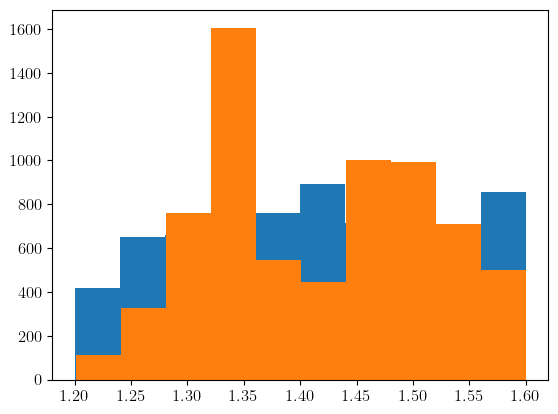

In [3]:
pop_mm = load_population_posterior('./mm/outdir_mm/results.h5')
pop_mm_full = load_population_posterior('./mm_full/outdir_mm/results.h5')
pop_gw = load_population_posterior('./gw/outdir_gw/results.h5')
plt.hist(pop_mm["k_coll"])
plt.hist(pop_mm_full["k_coll"])

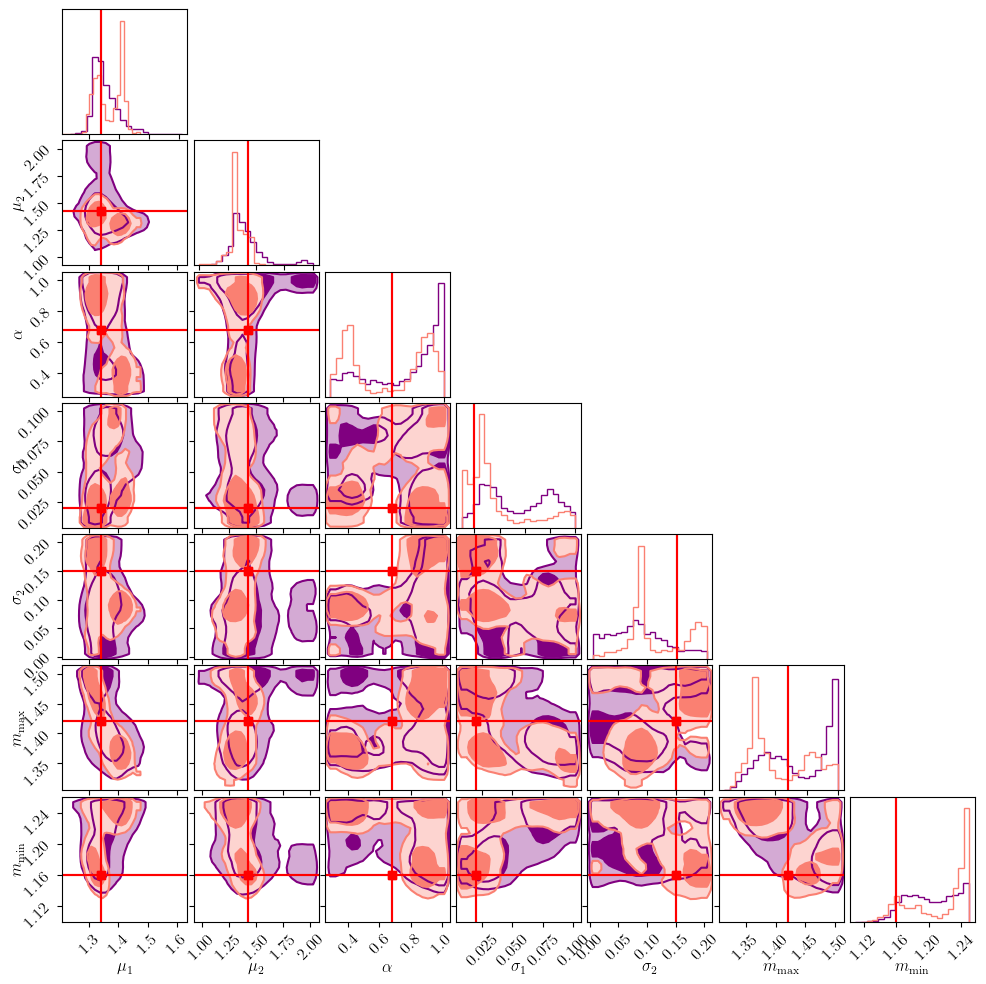

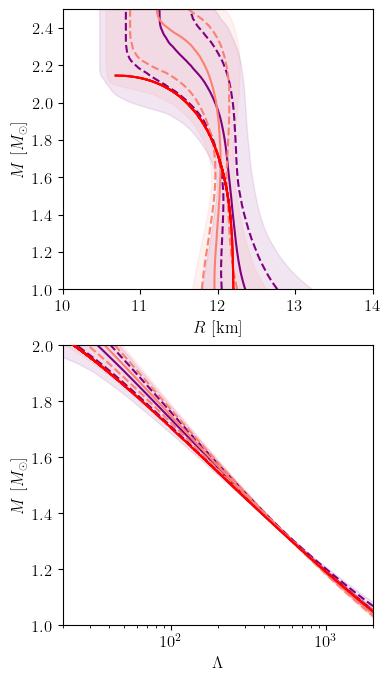

In [5]:
parameter_names = ["mu_1", "mu_2", "alpha", "sigma_1", "sigma_2", "m_max", "m_min"]
figs = plot_both("./gw/outdir_gw/results.h5", parameter_names=parameter_names);
#figs = plot_both("./gw/outdir_gw_1e-10_prior_cutoff/results.h5", parameter_names=parameter_names, figs=figs, color="salmon")
#figs = plot_both("./mm/outdir_mm/results.h5", parameter_names=parameter_names, figs=figs, color="orange")
figs = plot_both("./mm_full/outdir_mm/results.h5", parameter_names=parameter_names, figs=figs, color="salmon")
#figs = plot_both("./mm/outdir_mm_old_priorcutoff/results.h5", parameter_names=parameter_names, figs=figs, color="salmon")


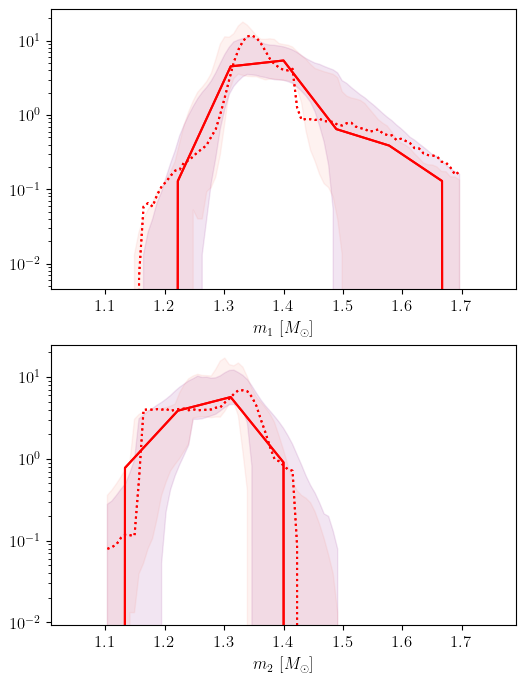

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(6,8))

plot_population(pop_gw, ax)
#plot_population(pop_mm, ax, color="orange")
plot_population(pop_mm_full, ax, color="salmon")

In [5]:
eos_posterior_gw = load_eos_posterior("./gw/outdir_gw/results.h5")
eos_posterior_mm = load_eos_posterior("./mm/outdir_mm/results.h5")
eos_posterior_mm_full = load_eos_posterior("./mm_full/outdir_mm/results.h5")

In [15]:
r14_samp_mm = np.vstack([np.interp(1.4, eos_posterior_mm["masses_EOS"][j,:], eos_posterior_mm["radii_EOS"][j,:], left=np.nan) 
                                     for j in range(eos_posterior_mm["masses_EOS"].shape[0]) 
    ])

r14_samp_mm_full = np.vstack([np.interp(1.4, eos_posterior_mm_full["masses_EOS"][j,:], eos_posterior_mm_full["radii_EOS"][j,:], left=np.nan) 
                                     for j in range(eos_posterior_mm_full["masses_EOS"].shape[0])
    ])

r14_samp_gw = np.vstack([np.interp(1.4, eos_posterior_gw["masses_EOS"][j,:], eos_posterior_gw["radii_EOS"][j,:], left=np.nan) 
                                     for j in range(eos_posterior_gw["masses_EOS"].shape[0]) 
    ])

weights_gw = np.loadtxt("./gw/outdir_gw/inverse_pdet.dat")
weights_mm = np.loadtxt("./mm/outdir_mm/inverse_pdet.dat")
weights_mm_full = np.loadtxt("./mm/outdir_mm/inverse_pdet.dat")

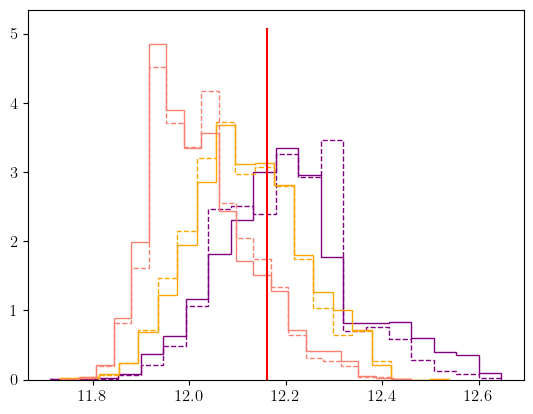

In [16]:

plt.hist(r14_samp_gw, color="purple", histtype="step", bins=20, density=True)
plt.hist(r14_samp_gw, color="purple", weights=weights_gw, histtype="step", bins=20, linestyle='dashed', density=True)

plt.hist(r14_samp_mm, color="orange", histtype="step", bins=20, density=True)
plt.hist(r14_samp_mm, color="orange", histtype="step", bins=20, density=True, weights=weights_mm, linestyle='dashed')

plt.hist(r14_samp_mm_full, color="salmon", histtype="step", bins=20, density=True)
plt.hist(r14_samp_mm_full, color="salmon", histtype="step", bins=20, density=True, weights=weights_mm_full, linestyle="dashed")

plt.vlines([np.interp(1.4, m_val, r_val)], *plt.gca().get_ylim(), color="red")

#plt.xlim(11.6, 12.7)